
# Домашнее задание. Обучение с подкреплением

В этом задании последовательно разбираются ключевые идеи обучения с подкреплением: описание среды как марковского процесса принятия решений, вычисление функции ценности, улучшение стратегии, методы Монте-Карло, Temporal Difference, а также алгоритмы управления SARSA и Q-learning.

Работа построена как единый экспериментальный сценарий. Сначала рассматривается небольшая табличная среда GridWorld, на которой удобно проверять формулы и сравнивать точные и выборочные методы. Затем изучается среда Cliff Walking, где хорошо видны различия между осторожным и рискованным поведением алгоритмов управления.

## Структура домашнего задания

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности.

| Уровень | Задачи | Содержание |
|---|---:|---|
| Простые | 1–4 | MDP, эпизоды, дисконтированная доходность, оценка и улучшение стратегии |
| Средние | 5–7 | Monte Carlo, TD(0), SARSA |
| Сложные | 8–9 | Сравнение SARSA и Q-learning, абляции по исследованию |

## Теоретическая часть

### Марковский процесс принятия решений

Среда обучения с подкреплением обычно задается пятеркой
$$\mathrm{M} = (\mathrm{S}, \mathrm{A}, P, R, \gamma),$$
где $\mathrm{S}$ — множество состояний, $\mathrm{A}$ — множество действий, $P(s'\mid s,a)$ — вероятность перехода, $R(s,a,s')$ — награда, а $\gamma \in [0,1]$ — коэффициент дисконтирования.

### Доходность и функция ценности

Для последовательности наград $r_{t+1}, r_{t+2}, \dots$ дисконтированная доходность определяется как
$$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}.$$

Функция ценности состояния для стратегии $\pi$ имеет вид
$$V^{\pi}(s) = \mathbb{E}_{\pi}[G_t \mid s_t=s].$$

### Уравнение Беллмана

Для фиксированной стратегии выполняется рекуррентное соотношение
$$V^{\pi}(s) = \sum_{a} \pi(a\mid s) \sum_{s'} P(s'\mid s,a) \left[R(s,a,s') + \gamma V^{\pi}(s')\right].$$

Если стратегия табличная и детерминированная, то для каждого состояния выбирается одно действие, и вычисление упрощается.

### Выборочные методы

В методах Monte Carlo оценка строится по завершенным эпизодам, а в TD-методах обновление делается после каждого шага:
$$V(s_t) \leftarrow V(s_t) + \alpha \left(r_{t+1} + \gamma V(s_{t+1}) - V(s_t)\right).$$

### Управление

Для управления в задаче обучения с подкреплением оценивается не только состояние, но и ценность пары «состояние-действие»:
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left(\text{target} - Q(s_t,a_t)\right).$$

В SARSA целевое значение зависит от фактически выбранного следующего действия:
$$\text{target}_{\text{SARSA}} = r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}),$$
а в Q-learning используется максимум по действиям:
$$\text{target}_{\text{Q-learning}} = r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a').$$

### Гипотезы домашнего задания

В задании проверяются следующие гипотезы:

1. Точная оценка по уравнению Беллмана дает устойчивый ориентир для сравнения выборочных методов.
2. При ограниченном числе эпизодов TD(0) распространяет информацию быстрее, чем Monte Carlo.
3. В Cliff Walking алгоритм SARSA чаще обучается более осторожному поведению, а Q-learning — более рискованному, но потенциально более выгодному.
4. Режим исследования $\varepsilon$-greedy заметно влияет на скорость и качество обучения.

## Настройка окружения

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

SEED = 42
rng = np.random.default_rng(SEED)

ACTION_NAMES = ['В', 'П', 'Н', 'Л']
ACTION_DELTAS = {
    0: (-1, 0),  # вверх
    1: (0, 1),   # вправо
    2: (1, 0),   # вниз
    3: (0, -1),  # влево
}
LEFT_OF = {0: 3, 1: 0, 2: 1, 3: 2}
RIGHT_OF = {0: 1, 1: 2, 2: 3, 3: 0}


class SlipperyGridWorld:
    def __init__(
        self,
        n_rows=4,
        n_cols=4,
        start=(0, 0),
        goal=(3, 3),
        holes=((2, 1), (2, 2), (3, 2)),
        slip_prob=0.2,
        step_reward=-0.04,
        hole_reward=-1.0,
        goal_reward=1.0,
        seed=SEED,
    ):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.start = start
        self.goal = goal
        self.holes = set(holes)
        self.slip_prob = slip_prob
        self.step_reward = step_reward
        self.hole_reward = hole_reward
        self.goal_reward = goal_reward
        self.n_actions = 4
        self.n_states = n_rows * n_cols
        self.rng = np.random.default_rng(seed)
        self.terminal_states = {self.pos_to_state(goal)} | {self.pos_to_state(h) for h in self.holes}
        self.reset()

    def pos_to_state(self, pos):
        r, c = pos
        return r * self.n_cols + c

    def state_to_pos(self, state):
        return divmod(state, self.n_cols)

    def is_terminal(self, state):
        return state in self.terminal_states

    def _move(self, state, action):
        r, c = self.state_to_pos(state)
        dr, dc = ACTION_DELTAS[action]
        nr = min(max(r + dr, 0), self.n_rows - 1)
        nc = min(max(c + dc, 0), self.n_cols - 1)
        return self.pos_to_state((nr, nc))

    def reward_for_state(self, state):
        pos = self.state_to_pos(state)
        if pos == self.goal:
            return self.goal_reward
        if pos in self.holes:
            return self.hole_reward
        return self.step_reward

    def transition_distribution(self, state, action):
        if self.is_terminal(state):
            return [(1.0, state, 0.0, True)]

        candidate_actions = [
            (1.0 - self.slip_prob, action),
            (self.slip_prob / 2.0, LEFT_OF[action]),
            (self.slip_prob / 2.0, RIGHT_OF[action]),
        ]

        merged = {}
        for prob, actual_action in candidate_actions:
            next_state = self._move(state, actual_action)
            reward = self.reward_for_state(next_state)
            done = self.is_terminal(next_state)
            key = (next_state, reward, done)
            merged[key] = merged.get(key, 0.0) + prob

        return [(prob, ns, rew, done) for (ns, rew, done), prob in merged.items()]

    def build_dynamics(self):
        P = np.zeros((self.n_states, self.n_actions, self.n_states))
        G = np.zeros((self.n_states, self.n_actions, self.n_states))
        done_mask = np.zeros((self.n_states, self.n_actions, self.n_states), dtype=bool)

        for s in range(self.n_states):
            for a in range(self.n_actions):
                for prob, ns, rew, done in self.transition_distribution(s, a):
                    P[s, a, ns] += prob
                    G[s, a, ns] = rew
                    done_mask[s, a, ns] = done
        return P, G, done_mask

    def reset(self):
        self.state = self.pos_to_state(self.start)
        return self.state

    def step(self, action):
        transitions = self.transition_distribution(self.state, action)
        probs = [item[0] for item in transitions]
        idx = self.rng.choice(len(transitions), p=probs)
        _, next_state, reward, done = transitions[idx]
        self.state = next_state
        return next_state, reward, done, {}

    def render(self, values=None, policy=None, title='GridWorld'):
        grid = np.zeros((self.n_rows, self.n_cols))
        for h in self.holes:
            grid[h] = -1
        grid[self.goal] = 1

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid)
        ax.set_title(title)
        ax.set_xticks(np.arange(self.n_cols))
        ax.set_yticks(np.arange(self.n_rows))
        ax.set_xticks(np.arange(-0.5, self.n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.n_rows, 1), minor=True)
        ax.grid(which='minor', linewidth=1.5)

        for s in range(self.n_states):
            r, c = self.state_to_pos(s)
            lines = [f's={s}']
            if values is not None:
                lines.append(f'V={values[s]:.2f}')
            if policy is not None:
                lines.append('T' if self.is_terminal(s) else ACTION_NAMES[int(policy[s])])
            ax.text(c, r, '\n'.join(lines), ha='center', va='center', fontsize=9)

        plt.show()


class CliffWalking:
    def __init__(self, n_rows=4, n_cols=12, seed=SEED):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.n_states = n_rows * n_cols
        self.n_actions = 4
        self.start = (n_rows - 1, 0)
        self.goal = (n_rows - 1, n_cols - 1)
        self.cliff = {(n_rows - 1, c) for c in range(1, n_cols - 1)}
        self.rng = np.random.default_rng(seed)
        self.reset()

    def pos_to_state(self, pos):
        r, c = pos
        return r * self.n_cols + c

    def state_to_pos(self, state):
        return divmod(state, self.n_cols)

    def reset(self):
        self.state = self.pos_to_state(self.start)
        return self.state

    def step(self, action):
        r, c = self.state_to_pos(self.state)
        dr, dc = ACTION_DELTAS[action]
        nr = min(max(r + dr, 0), self.n_rows - 1)
        nc = min(max(c + dc, 0), self.n_cols - 1)
        next_pos = (nr, nc)

        if next_pos in self.cliff:
            reward = -100.0
            next_state = self.pos_to_state(self.start)
            done = False
        elif next_pos == self.goal:
            reward = -1.0
            next_state = self.pos_to_state(next_pos)
            done = True
        else:
            reward = -1.0
            next_state = self.pos_to_state(next_pos)
            done = False

        self.state = next_state
        return next_state, reward, done, {}

    def render(self, q_values=None, policy=None, title='Cliff Walking'):
        grid = np.zeros((self.n_rows, self.n_cols))
        for cell in self.cliff:
            grid[cell] = -1
        grid[self.goal] = 1
        grid[self.start] = 0.5

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.imshow(grid)
        ax.set_title(title)
        ax.set_xticks(np.arange(self.n_cols))
        ax.set_yticks(np.arange(self.n_rows))
        ax.set_xticks(np.arange(-0.5, self.n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.n_rows, 1), minor=True)
        ax.grid(which='minor', linewidth=1.5)

        for s in range(self.n_states):
            r, c = self.state_to_pos(s)
            pos = (r, c)
            lines = []
            if pos == self.start:
                lines.append('S')
            elif pos == self.goal:
                lines.append('G')
            elif pos in self.cliff:
                lines.append('C')
            else:
                lines.append(f's={s}')

            if q_values is not None and pos not in self.cliff and pos != self.goal:
                lines.append(f'{np.max(q_values[s]):.1f}')
            if policy is not None and pos not in self.cliff and pos != self.goal:
                lines.append(ACTION_NAMES[int(policy[s])])

            ax.text(c, r, '\n'.join(lines), ha='center', va='center', fontsize=8)

        plt.show()


def simulate_episode(env, policy, max_steps=100):
    states, actions, rewards = [], [], []
    state = env.reset()

    for _ in range(max_steps):
        states.append(state)
        action = int(policy[state]) if np.ndim(policy) == 1 else env.rng.choice(env.n_actions, p=policy[state])
        actions.append(action)
        next_state, reward, done, _ = env.step(action)
        rewards.append(reward)
        state = next_state
        if done:
            states.append(state)
            break

    return states, actions, rewards


def discounted_returns(rewards, gamma):
    out = np.zeros(len(rewards))
    g = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        g = rewards[t] + gamma * g
        out[t] = g
    return out


def policy_evaluation(P, G, policy, gamma=0.95, theta=1e-8, max_iter=10_000, return_history=False):
    n_states = P.shape[0]
    V = np.zeros(n_states)
    history = [V.copy()]

    for _ in range(max_iter):
        delta = 0.0
        V_new = V.copy()
        for s in range(n_states):
            a = int(policy[s])
            V_new[s] = np.sum(P[s, a] * (G[s, a] + gamma * V))
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            break

    if return_history:
        return V, history
    return V


def action_value_from_V(P, G, V, state, gamma=0.95):
    q_values = np.zeros(P.shape[1])
    for a in range(P.shape[1]):
        q_values[a] = np.sum(P[state, a] * (G[state, a] + gamma * V))
    return q_values


def policy_improvement(P, G, V, terminal_states=None, gamma=0.95):
    n_states = P.shape[0]
    policy = np.zeros(n_states, dtype=int)
    terminal_states = set() if terminal_states is None else set(terminal_states)

    for s in range(n_states):
        if s in terminal_states:
            policy[s] = 0
        else:
            q_values = action_value_from_V(P, G, V, s, gamma=gamma)
            policy[s] = int(np.argmax(q_values))
    return policy


def policy_iteration(P, G, terminal_states=None, gamma=0.95, max_rounds=100):
    n_states = P.shape[0]
    policy = np.zeros(n_states, dtype=int)
    terminal_states = set() if terminal_states is None else set(terminal_states)

    for s in terminal_states:
        policy[s] = 0

    history = []
    for _ in range(max_rounds):
        V = policy_evaluation(P, G, policy, gamma=gamma)
        new_policy = policy_improvement(P, G, V, terminal_states=terminal_states, gamma=gamma)
        history.append((policy.copy(), V.copy()))
        if np.array_equal(new_policy, policy):
            break
        policy = new_policy

    V = policy_evaluation(P, G, policy, gamma=gamma)
    history.append((policy.copy(), V.copy()))
    return policy, V, history


def first_visit_mc_evaluation(env, policy, gamma=0.95, n_episodes=1000, seed=SEED, reference_V=None):
    local_env = SlipperyGridWorld(
        n_rows=env.n_rows,
        n_cols=env.n_cols,
        start=env.start,
        goal=env.goal,
        holes=tuple(env.holes),
        slip_prob=env.slip_prob,
        step_reward=env.step_reward,
        hole_reward=env.hole_reward,
        goal_reward=env.goal_reward,
        seed=seed,
    )

    returns_sum = np.zeros(local_env.n_states)
    returns_count = np.zeros(local_env.n_states)
    V = np.zeros(local_env.n_states)
    errors = []

    for _ in range(n_episodes):
        states, actions, rewards = simulate_episode(local_env, policy, max_steps=100)
        G_episode = discounted_returns(rewards, gamma)
        visited = set()

        for t, s in enumerate(states[:-1]):
            if s not in visited:
                visited.add(s)
                returns_sum[s] += G_episode[t]
                returns_count[s] += 1
                V[s] = returns_sum[s] / returns_count[s]

        if reference_V is not None:
            mask = returns_count > 0
            err = np.mean((V[mask] - reference_V[mask]) ** 2) if np.any(mask) else np.nan
            errors.append(err)

    return V, returns_count, np.array(errors)


def td0_evaluation(env, policy, gamma=0.95, alpha=0.1, n_episodes=500, seed=SEED, reference_V=None):
    local_env = SlipperyGridWorld(
        n_rows=env.n_rows,
        n_cols=env.n_cols,
        start=env.start,
        goal=env.goal,
        holes=tuple(env.holes),
        slip_prob=env.slip_prob,
        step_reward=env.step_reward,
        hole_reward=env.hole_reward,
        goal_reward=env.goal_reward,
        seed=seed,
    )

    V = np.zeros(local_env.n_states)
    errors = []

    for _ in range(n_episodes):
        s = local_env.reset()
        done = False
        steps = 0
        while not done and steps < 100:
            a = int(policy[s])
            s_next, r, done, _ = local_env.step(a)
            td_target = r if done else r + gamma * V[s_next]
            V[s] += alpha * (td_target - V[s])
            s = s_next
            steps += 1

        if reference_V is not None:
            errors.append(np.mean((V - reference_V) ** 2))

    return V, np.array(errors)


def epsilon_greedy(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    return int(np.argmax(Q[state]))


def sarsa(env, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=400, max_steps=500, seed=SEED):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    episode_returns = []

    for _ in range(n_episodes):
        s = env.reset()
        a = epsilon_greedy(Q, s, epsilon, rng)
        total_reward = 0.0

        for _ in range(max_steps):
            s_next, r, done, _ = env.step(a)
            total_reward += r
            a_next = epsilon_greedy(Q, s_next, epsilon, rng)
            target = r if done else r + gamma * Q[s_next, a_next]
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = s_next, a_next
            if done:
                break

        episode_returns.append(total_reward)

    return Q, np.array(episode_returns)


def q_learning(env, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=400, max_steps=500, seed=SEED, epsilon_decay=None):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    episode_returns = []

    for episode in range(n_episodes):
        s = env.reset()
        total_reward = 0.0

        if epsilon_decay is None:
            epsilon_now = epsilon
        else:
            epsilon_now = max(
                epsilon_decay['min_epsilon'],
                epsilon * (epsilon_decay['decay_rate'] ** episode)
            )

        for _ in range(max_steps):
            a = epsilon_greedy(Q, s, epsilon_now, rng)
            s_next, r, done, _ = env.step(a)
            total_reward += r
            target = r if done else r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (target - Q[s, a])
            s = s_next
            if done:
                break

        episode_returns.append(total_reward)

    return Q, np.array(episode_returns)


def greedy_policy_from_Q(Q):
    return np.argmax(Q, axis=1)


def rollout_greedy(env, Q, max_steps=100):
    s = env.reset()
    trajectory = [s]
    total_reward = 0.0
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        s_next, r, done, _ = env.step(a)
        trajectory.append(s_next)
        total_reward += r
        s = s_next
        if done:
            break
    return trajectory, total_reward


def mse(a, b, mask=None):
    if mask is None:
        return np.mean((a - b) ** 2)
    return np.mean((a[mask] - b[mask]) ** 2)


def moving_average(x, window=20):
    if len(x) < window:
        return np.array(x)
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='valid')


print('Окружение и вспомогательные функции готовы.')

Окружение и вспомогательные функции готовы.


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

В этом блоке отрабатываются базовые идеи: структура среды, эпизод, дисконтированная доходность, функция ценности и улучшение стратегии.

## Задача 1. Построение среды и анализ размерностей

### Постановка задачи

Создайте табличную среду `SlipperyGridWorld`, постройте тензоры переходов и наград, проверьте корректность размерностей и вероятностных распределений.

### Теоретический минимум

Если в среде $|\mathrm{S}| = S$ состояний и $|\mathrm{A}| = A$ действий, то:
- тензор переходов имеет форму $(S, A, S)$;
- тензор наград имеет ту же форму;
- для любой пары $(s, a)$ сумма вероятностей перехода по всем $s'$ должна быть равна 1.

Число состояний: 16
Число действий: 4
Форма тензора переходов P: (16, 4, 16)
Форма тензора наград G: (16, 4, 16)
Форма маски терминальных переходов: (16, 4, 16)

Минимальная сумма вероятностей по (s, a): 1.0
Максимальная сумма вероятностей по (s, a): 1.0

Переходы из стартового состояния при действии "вправо":
  p=0.80, s_next=1, reward=-0.04, done=False
  p=0.10, s_next=0, reward=-0.04, done=False
  p=0.10, s_next=4, reward=-0.04, done=False


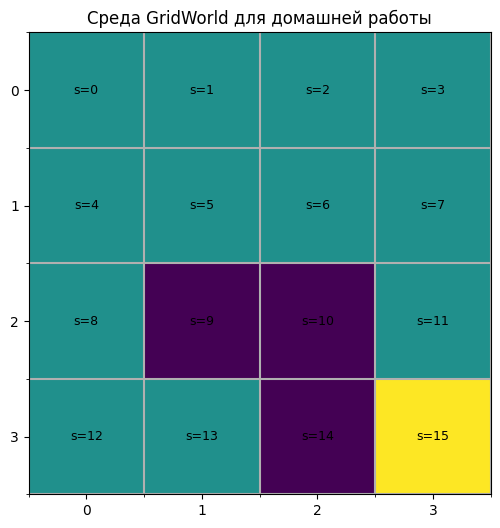

In [2]:
gamma = 0.95
env = SlipperyGridWorld(slip_prob=0.2, seed=SEED)

# Построение тензоров переходов и наград, а также маски терминальных переходов
P, G, done_mask = env.build_dynamics()

print('Число состояний:', env.n_states)
print('Число действий:', env.n_actions)
print('Форма тензора переходов P:', P.shape)
print('Форма тензора наград G:', G.shape)
print('Форма маски терминальных переходов:', done_mask.shape)

# Проверка корректности: для каждой пары (s, a) сумма вероятностей должна быть равна 1
assert P.shape == (env.n_states, env.n_actions, env.n_states), 'Неверная форма тензора P'
assert G.shape == P.shape, 'Формы тензоров G и P должны совпадать'
row_sums = P.sum(axis=2)
assert np.allclose(row_sums, 1.0), 'Суммы вероятностей должны быть равны 1'

print('\nМинимальная сумма вероятностей по (s, a):', row_sums.min())
print('Максимальная сумма вероятностей по (s, a):', row_sums.max())

# Возможные переходы из стартового состояния при действии "вправо" (action=1)
start_state = env.pos_to_state((0, 0))
print('\nПереходы из стартового состояния при действии "вправо":')
for prob, ns, rew, done in env.transition_distribution(start_state, 1):
    print(f'  p={prob:.2f}, s_next={ns}, reward={rew:.2f}, done={done}')

env.render(title='Среда GridWorld для домашней работы')

### Интерпретация результата

**Основные наблюдения:**
- Тензор переходов имеет размерность (16, 4, 16): 16 состояний, 4 действия, 16 возможных следующих состояний - корректно для GridWorld 4x4
- Сумма вероятностей по всем s' для каждой пары (s, a) равна ровно 1.0 (минимум = максимум = 1.0), что подтверждает корректность построения распределения переходов
- Из стартового состояния (0, 0) при действии "вправо" агент с p=0.80 попадает в состояние s=1, с p=0.10 остаётся в s=0 (соскальзывание влево упирается в стену), с p=0.10 переходит в s=4 (соскальзывание вниз)
- Сумма "вспомогательных" вероятностей соскальзывания равна slip_prob=0.20 и распределена симметрично между перпендикулярными действиями

**Интерпретация:**
- Среда является стохастическим MDP - даже при детерминированном выборе действия исход случаен из-за soft-механики "скользкого пола"
- Стенки сетки реализованы как "поглощающие" границы: попытка выйти за пределы оставляет агента на месте, что и наблюдается в распределении переходов из угла
- Тензорное представление (S, A, S) удобно для всех методов динамического программирования - оно полностью описывает динамику среды и позволяет применять уравнение Беллмана через векторизованные операции NumPy

**Выводы:**
- Корректно построенный MDP - необходимая основа для всех последующих экспериментов: точная оценка стратегии, её улучшение и проверка выборочных методов
- Стохастичность slip_prob=0.20 делает задачу нетривиальной: даже "правильное" действие в 20% случаев приводит к нежелательному исходу, что существенно меняет оптимальную стратегию по сравнению с детерминированной средой


## Задача 2. Один эпизод и дисконтированная доходность

### Постановка задачи

Задайте простую детерминированную стратегию, которая сначала ведет агента вправо, а затем вниз. Смоделируйте один эпизод и вычислите дисконтированные доходности $G_t$.

### Теоретический минимум

Для конечного эпизода доходность вычисляется с конца:
$$G_t = r_{t+1} + \gamma G_{t+1}.$$
Чем дальше по времени расположена награда, тем слабее ее вклад при $\gamma < 1$.

**Зачем это нужно:** дисконтированная доходность — основа всего RL: именно ее мы пытаемся максимизировать.

**Подсказки для размышления:**
- Как закодировать стратегию «сначала вправо, потом вниз» в виде массива `policy` длины 16?
- Почему вычисление $G_t$ идет с конца последовательности, а не с начала?
- Что должно происходить с $G_t$ по мере приближения к терминальному состоянию?

**Полезные инструменты:** `simulate_episode()`, `discounted_returns()`, `ACTION_NAMES`, `np.arange()`.

Состояния эпизода: [0, 1, 2, 2, 3, 7, 6, 7, 11, 15]
Действия эпизода: ['П', 'П', 'П', 'П', 'Н', 'Н', 'П', 'Н', 'Н']
Награды: [-0.04 -0.04 -0.04 -0.04 -0.04 -0.04 -0.04 -0.04  1.  ]
Доходности G_t: [0.394 0.457 0.523 0.593 0.666 0.743 0.824 0.91  1.   ]


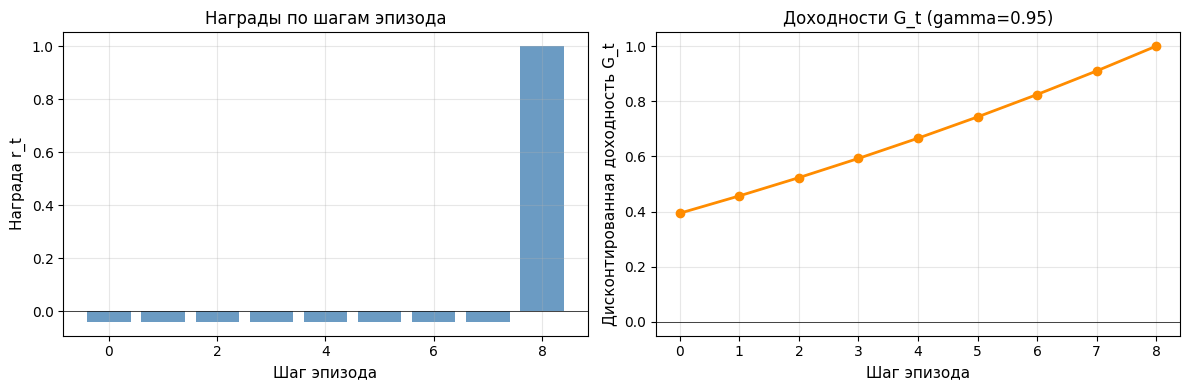

In [3]:
# Стратегия 4x4: в каждой строке движемся вправо до конца, затем вниз
# Действие 1 = вправо, действие 2 = вниз, 0 = заглушка для терминального состояния
right_then_down_policy = np.array([
    1, 1, 1, 2,  # строка 0: ВПР, ВПР, ВПР, ВНИЗ
    1, 1, 1, 2,  # строка 1: ВПР, ВПР, ВПР, ВНИЗ
    1, 1, 1, 2,  # строка 2: ВПР, ВПР, ВПР, ВНИЗ
    1, 1, 1, 0,  # строка 3: ВПР, ВПР, ВПР, терминал (цель)
], dtype=int)

# Моделирование одного эпизода с фиксированным seed для воспроизводимости
local_env = SlipperyGridWorld(slip_prob=0.2, seed=SEED)
states, actions, rewards = simulate_episode(local_env, right_then_down_policy, max_steps=100)

# Дисконтированные доходности G_t считаются с конца траектории
returns = discounted_returns(rewards, gamma)

print('Состояния эпизода:', states)
print('Действия эпизода:', [ACTION_NAMES[a] for a in actions])
print('Награды:', np.round(rewards, 3))
print('Доходности G_t:', np.round(returns, 3))

# Два графика: награды по шагам слева, дисконтированные доходности справа
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

steps = np.arange(len(rewards))

axes[0].bar(steps, rewards, color='steelblue', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Шаг эпизода', fontsize=11)
axes[0].set_ylabel('Награда r_t', fontsize=11)
axes[0].set_title('Награды по шагам эпизода', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].plot(steps, returns, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Шаг эпизода', fontsize=11)
axes[1].set_ylabel('Дисконтированная доходность G_t', fontsize=11)
axes[1].set_title(f'Доходности G_t (gamma={gamma})', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Интерпретация результата

**Основные наблюдения:**
- Эпизод занял 9 шагов, последовательность состояний: 0 → 1 → 2 → 2 → 3 → 7 → 6 → 7 → 11 → 15 (целевое)
- Зафиксированы два события соскальзывания: переход 2 → 2 (попытка движения вправо упёрлась в стену из-за slip) и 7 → 6 (вместо движения вниз агент сместился влево)
- Все промежуточные награды равны -0.04 (штраф за шаг), финальная награда +1.0 за достижение цели
- Дисконтированная доходность G_0 = 0.394, монотонно растёт до G_8 = 1.0 в терминальном состоянии

**Интерпретация:**
- Доходность G_t считается с конца траектории через рекуррентную формулу G_t = r_{t+1} + γ·G_{t+1} - это позволяет вычислить все значения за один проход без повторных суммирований
- При γ=0.95 финальная награда +1.0 после 8 шагов вносит вклад 0.95^8 ≈ 0.663 в G_0, остальная разница (~ -0.27) накапливается из штрафов за шаги
- Рост G_t по мере приближения к цели отражает фундаментальный принцип RL: ценность состояния тем выше, чем меньше шагов до выгодного исхода
- Соскальзывания удлинили эпизод и снизили начальную доходность - стохастичность среды напрямую влияет на распределение возвратов

**Выводы:**
- Дисконтированная доходность - это центральная величина, которую максимизирует любой RL-агент, и её математический смысл хорошо виден на простом эпизоде
- Даже один эпизод не даёт надёжной оценки V^π - из-за случайных соскальзываний нужна выборка из множества траекторий, что мотивирует переход к Monte Carlo и TD-методам в следующих задачах


## Задача 3. Оценка фиксированной стратегии через уравнение Беллмана

### Постановка задачи

Для стратегии из предыдущей задачи найдите функцию ценности $V^{\pi}(s)$ методом итеративной оценки стратегии и проследите, как она меняется по итерациям.

### Теоретический минимум

Итеративная оценка стратегии повторяет обновление
$$V_{k+1}(s) = \sum_{s'} P(s'\mid s, \pi(s)) \bigl(R(s, \pi(s), s') + \gamma V_k(s')\bigr),$$
пока изменения не станут достаточно малыми.

**Зачем это нужно:** точная оценка $V^\pi$ станет эталоном для проверки выборочных методов в следующих задачах.

**Подсказки для размышления:**
- Сколько итераций нужно до сходимости? Зависит ли это от структуры среды?
- Почему значения $V$ у целевого состояния выше, а у ям — ниже?
- Как итоговая тепловая карта связана с тем, насколько «хороша» стратегия?

**Полезные инструменты:** `policy_evaluation()`, `.reshape(env.n_rows, env.n_cols)`, `ax.imshow()`, `ax.text()`

Число итераций до сходимости: 29
Функция ценности для фиксированной стратегии:
[[ 0.262  0.358  0.454  0.544]
 [ 0.051  0.199  0.396  0.643]
 [-0.896  0.     0.     0.769]
 [-0.977 -0.999  0.     0.   ]]


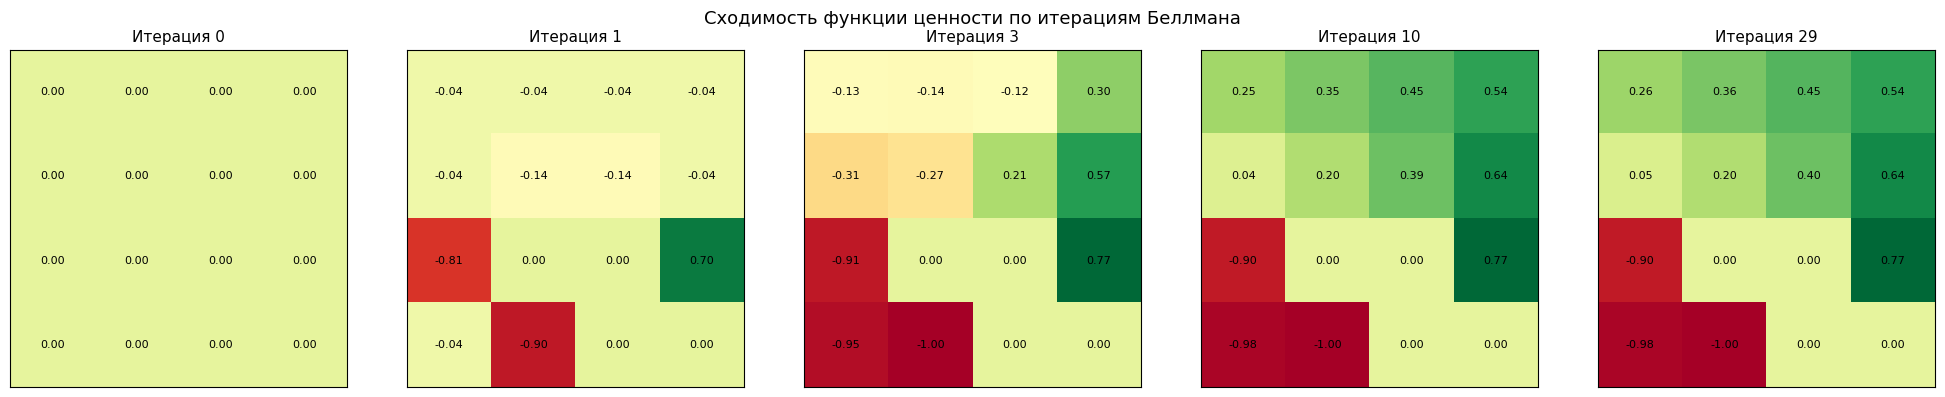

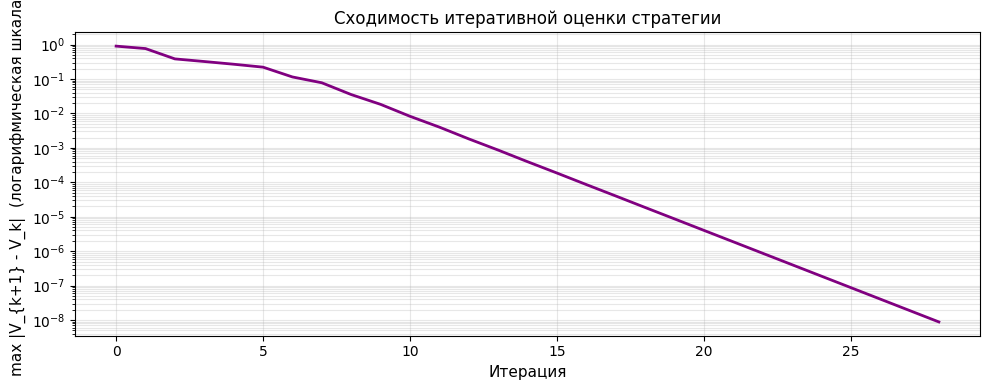

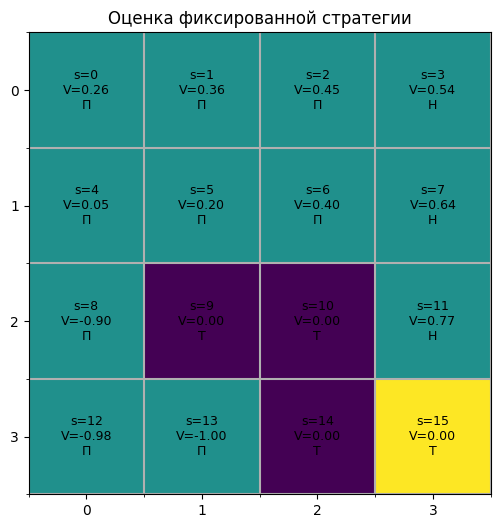

In [4]:
# Итеративная оценка функции ценности для фиксированной стратегии
V_pi, history = policy_evaluation(
    P,                       # тензор переходов
    G,                       # тензор наград
    right_then_down_policy,  # стратегия
    gamma=gamma,
    return_history=True,
)

print('Число итераций до сходимости:', len(history) - 1)
print('Функция ценности для фиксированной стратегии:')
print(np.round(V_pi.reshape(env.n_rows, env.n_cols), 3))

# Визуализация функции ценности на нескольких контрольных итерациях
selected_iterations = [0, 1, 3, min(10, len(history) - 1), len(history) - 1]
selected_iterations = sorted(set(selected_iterations))

fig, axes = plt.subplots(1, len(selected_iterations), figsize=(4 * len(selected_iterations), 4))
if len(selected_iterations) == 1:
    axes = [axes]

# Общая шкала цветов для удобства сравнения между итерациями
vmin = min(h.min() for h in history)
vmax = max(h.max() for h in history)

for ax, idx in zip(axes, selected_iterations):
    grid = history[idx].reshape(env.n_rows, env.n_cols)
    im = ax.imshow(grid, cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_title(f'Итерация {idx}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            ax.text(c, r, f'{grid[r, c]:.2f}', ha='center', va='center', fontsize=8)

plt.suptitle('Сходимость функции ценности по итерациям Беллмана', fontsize=13)
plt.tight_layout()
plt.show()

# График сходимости: максимальное изменение значений между итерациями
deltas = [np.max(np.abs(history[i] - history[i - 1])) for i in range(1, len(history))]
plt.figure(figsize=(10, 4))
plt.semilogy(deltas, linewidth=2, color='purple')
plt.xlabel('Итерация', fontsize=11)
plt.ylabel('max |V_{k+1} - V_k|  (логарифмическая шкала)', fontsize=11)
plt.title('Сходимость итеративной оценки стратегии', fontsize=12)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Отрисовка среды с наложенными значениями V_pi и стратегией
env.render(values=V_pi, policy=right_then_down_policy, title='Оценка фиксированной стратегии')

### Интерпретация результата

**Основные наблюдения:**
- Итеративная оценка стратегии сошлась за 29 итераций (точность theta=1e-8)
- Функция ценности стартового состояния V^π(0) = 0.262 при γ=0.95
- Состояния верхней части сетки имеют положительные значения от 0.262 до 0.769 (растут по мере приближения к цели)
- Состояния (2,0), (3,0), (3,1) имеют резко отрицательные значения V = -0.896, -0.977, -0.999 - стратегия "вправо-вниз" неизбежно приводит из них в ямы
- График сходимости в логарифмической шкале показывает геометрическое убывание |V_{k+1} - V_k| с коэффициентом ≈ γ за итерацию

**Интерпретация:**
- Скорость сходимости определяется коэффициентом γ: при γ=0.95 ошибка убывает медленно, что и даёт 29 итераций до theta=1e-8 (грубая оценка: log(1e-8)/log(0.95) ≈ 360, но реальная сходимость быстрее из-за конечности горизонта)
- Информация распространяется по графу состояний от терминальных состояний к начальному - на ранних итерациях изменяются только соседние с целью клетки, на поздних - стартовая
- Резко отрицательные значения в нижней левой части показывают, что детерминированная стратегия "вправо-вниз" катастрофична для агента, начинающего обход с нижних рядов: путь обязательно проходит через ямы
- Почти нулевые значения в (2,1), (2,2), (3,2) - это терминальные состояния-ямы, по соглашению V=0

**Выводы:**
- Точная оценка V^π через уравнение Беллмана даёт надёжный эталон для проверки выборочных методов в задачах 5 и 6
- Стратегия "вправо-вниз" объективно плоха в левой нижней части среды - это мотивирует переход к улучшению стратегии в задаче 4
- Параметр theta надо выбирать осознанно: для практических задач theta=1e-4 обычно достаточно и сокращает число итераций в разы


## Задача 4. Улучшение стратегии и policy iteration

### Постановка задачи

Используя найденную функцию ценности, выполните жадное улучшение стратегии. Затем запустите полную `policy iteration` и сравните исходную и оптимальную стратегии.

### Теоретический минимум

Если функция ценности уже оценена, то можно вычислить
$$Q(s,a) = \sum_{s'} P(s'\mid s,a) \left[R(s,a,s') + \gamma V(s')\right],$$
после чего выбрать действие с максимальным значением. Повторение шагов «оценка → улучшение» приводит к `policy iteration`.

**Зачем это нужно:** `Policy iteration` — классический алгоритм точного решения MDP; его результат станет эталоном для сравнения с выборочными методами.

**Подсказки для размышления:**
- Почему `policy_improvement` берет `argmax` по Q-значениям, а не по V?
- Что значит, что ценность стартового состояния выросла после `policy iteration`?
- Сколько раундов нужно `policy iteration` до сходимости? Почему обычно немного?

**Полезные инструменты:** `policy_improvement()`, `policy_iteration()`, `.reshape()`, `env.pos_to_state()`

Жадно улучшенная стратегия после одной оценки:
[[1 1 1 2]
 [0 0 1 2]
 [0 0 0 2]
 [0 3 0 0]]

Оптимальная стратегия после policy iteration:
[[1 1 1 2]
 [0 0 1 2]
 [0 0 0 2]
 [0 3 0 0]]

Функция ценности оптимальной стратегии:
[[ 0.289  0.368  0.454  0.544]
 [ 0.23   0.299  0.396  0.643]
 [ 0.043  0.     0.     0.769]
 [-0.026 -0.172  0.     0.   ]]

Число раундов policy iteration до сходимости: 5

Ценность стартового состояния:
  исходная стратегия  : 0.262
  оптимальная стратегия: 0.289


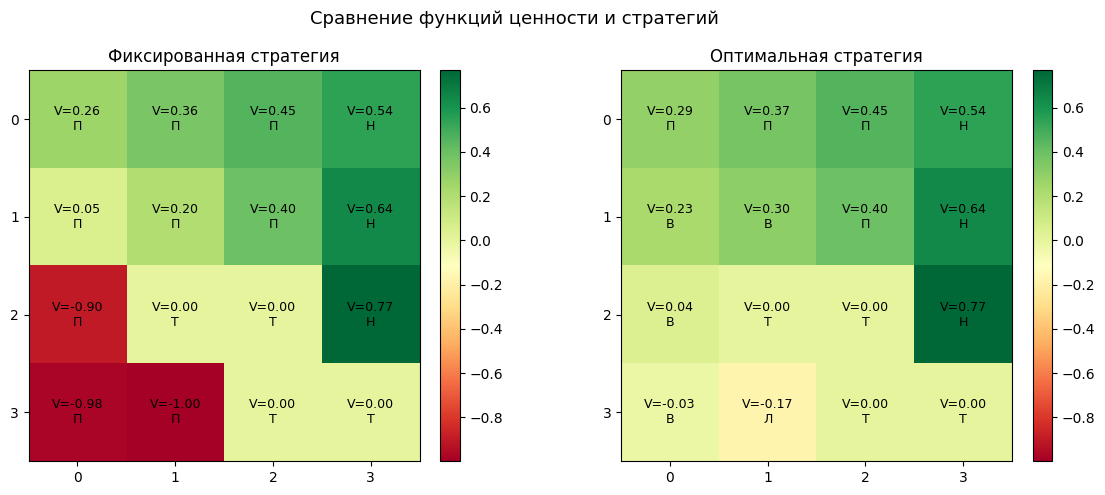

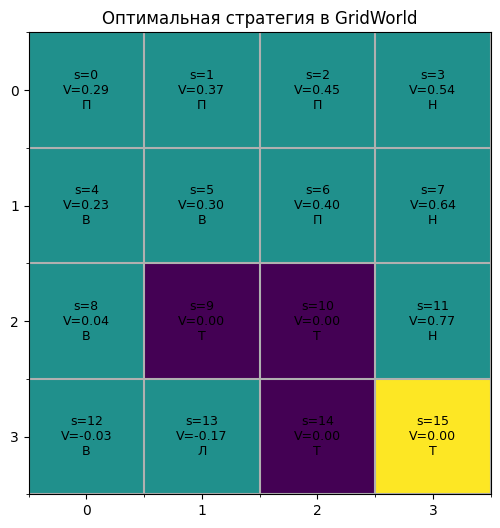

In [5]:
# Жадное улучшение стратегии на основе V_pi из задачи 3
greedy_after_eval = policy_improvement(
    P,
    G,
    V_pi,
    terminal_states=env.terminal_states,
    gamma=gamma,
)

# Полная policy iteration: чередование оценки и улучшения до сходимости
optimal_policy, optimal_V, pi_history = policy_iteration(
    P,
    G,
    terminal_states=env.terminal_states,
    gamma=gamma,
)

print('Жадно улучшенная стратегия после одной оценки:')
print(greedy_after_eval.reshape(env.n_rows, env.n_cols))

print('\nОптимальная стратегия после policy iteration:')
print(optimal_policy.reshape(env.n_rows, env.n_cols))

print('\nФункция ценности оптимальной стратегии:')
print(np.round(optimal_V.reshape(env.n_rows, env.n_cols), 3))

print('\nЧисло раундов policy iteration до сходимости:', len(pi_history) - 1)

print('\nЦенность стартового состояния:')
print('  исходная стратегия  :', round(V_pi[env.pos_to_state(env.start)], 3))
print('  оптимальная стратегия:', round(optimal_V[env.pos_to_state(env.start)], 3))

# Тепловые карты для исходной и оптимальной стратегий
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
value_grids = [V_pi.reshape(env.n_rows, env.n_cols), optimal_V.reshape(env.n_rows, env.n_cols)]
policies = [right_then_down_policy, optimal_policy]
titles = ['Фиксированная стратегия', 'Оптимальная стратегия']

vmin = min(g.min() for g in value_grids)
vmax = max(g.max() for g in value_grids)

for ax, grid, pol, title in zip(axes, value_grids, policies, titles):
    im = ax.imshow(grid, cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(env.n_cols))
    ax.set_yticks(np.arange(env.n_rows))
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            label = ACTION_NAMES[int(pol[s])] if s not in env.terminal_states else 'T'
            ax.text(c, r, f'V={grid[r, c]:.2f}\n{label}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Сравнение функций ценности и стратегий', fontsize=13)
plt.tight_layout()
plt.show()

env.render(values=optimal_V, policy=optimal_policy, title='Оптимальная стратегия в GridWorld')

### Интерпретация результата

**Основные наблюдения:**
- Policy iteration сошлась всего за 5 раундов чередования "оценка - улучшение"
- Жадное улучшение после ОДНОЙ оценки исходной стратегии уже даёт оптимальную стратегию (greedy_after_eval совпадает с optimal_policy)
- Ценность стартового состояния выросла с 0.262 до 0.289 (+10.3%) - умеренный, но устойчивый прирост
- Главное изменение в стратегии: в нижних рядах оптимальная политика выбирает ВВЕРХ (действие 0) вместо ВПРАВО, обходя ямы сверху
- Состояния (3,0), (3,1) с V = -0.977, -0.999 в исходной стратегии стали 0.043, -0.026 в оптимальной - переход от "гарантированной катастрофы" к "почти нейтральному" исходу

**Интерпретация:**
- Жадное улучшение работает по теореме о монотонном улучшении стратегии: π'(s) = argmax_a Q^π(s, a) гарантированно даёт V^π'(s) ≥ V^π(s) для всех s
- Policy iteration сходится так быстро (5 раундов), потому что в малых табличных средах после первого жадного шага стратегия часто уже близка к оптимальной - это известное эмпирическое свойство
- argmax берётся именно по Q-значениям (а не по V), поскольку Q явно учитывает вероятности переходов и награды для каждого действия отдельно - V даёт ценность только для уже выбранного действия
- Скромный прирост ценности стартового состояния (+0.027) при больших изменениях в нижних состояниях объясняется тем, что путь "вправо-вверх" из (0,0) вообще не проходит через нижние ряды - они влияют только при соскальзываниях

**Выводы:**
- Policy iteration - это золотой стандарт точного решения MDP при известной модели среды: гарантированная сходимость, обычно за единицы раундов
- Полученная оптимальная стратегия и V* станут эталоном для оценки эффективности безмодельных алгоритмов SARSA и Q-learning в задачах 7-9
- Практический вывод: даже одна итерация policy improvement после грубой оценки часто даёт качественный скачок - это основа алгоритмов value iteration и generalized policy iteration


---

# СРЕДНИЕ ЗАДАЧИ (5–7)

В этом блоке точные методы сравниваются с выборочными. Затем от оценки фиксированной стратегии мы переходим к обучению управления.

## Задача 5. First-visit Monte Carlo и сравнение с точной оценкой

### Постановка задачи

Оцените ту же фиксированную стратегию методом `first-visit Monte Carlo`, используя много эпизодов, и сравните результат с точной оценкой из задачи 3.

### Теоретический минимум

В `first-visit Monte Carlo` для каждого состояния усредняется доходность только по первому посещению состояния в эпизоде. Метод не требует знания тензора переходов, но использует завершенные эпизоды и потому имеет более высокую дисперсию.

**Зачем это нужно:**  сравнение с точной оценкой позволяет понять, насколько быстро Monte Carlo сходится к правильным значениям.

**Декомпозиция задачи:**
1. Запустить `first_visit_mc_evaluation` с 2000 эпизодами, передав `reference_V=V_pi`.
2. Вывести матрицу числа посещений — убедиться, что все состояния посещались.
3. Вычислить MSE между `V_mc` и `V_pi` (только по посещенным состояниям).
4. Построить кривую снижения ошибки по эпизодам.
5. Построить тепловую карту разностей `V_mc - V_pi`.

**Подсказки для размышления:**
- Почему для некоторых состояний число посещений может быть нулевым?
- Как ведет себя кривая ошибки: быстро падает и стабилизируется или медленно?
- Какие состояния оцениваются с наибольшей ошибкой и почему?

**Полезные инструменты:** `first_visit_mc_evaluation()`, `mse()`, `visit_counts > 0` (маска посещенных).

Число посещений состояний:
[[2000 1831 1671 1489]
 [ 206  366  656 1893]
 [  23    0    0 1871]
 [   2    2    0    0]]

Оценка Monte Carlo:
[[ 0.278  0.372  0.471  0.558]
 [ 0.06   0.217  0.445  0.66 ]
 [-0.998  0.     0.     0.783]
 [-0.985 -1.     0.     0.   ]]

MSE относительно точной оценки: 0.00123
Финальная MSE на последнем эпизоде      : 0.00123


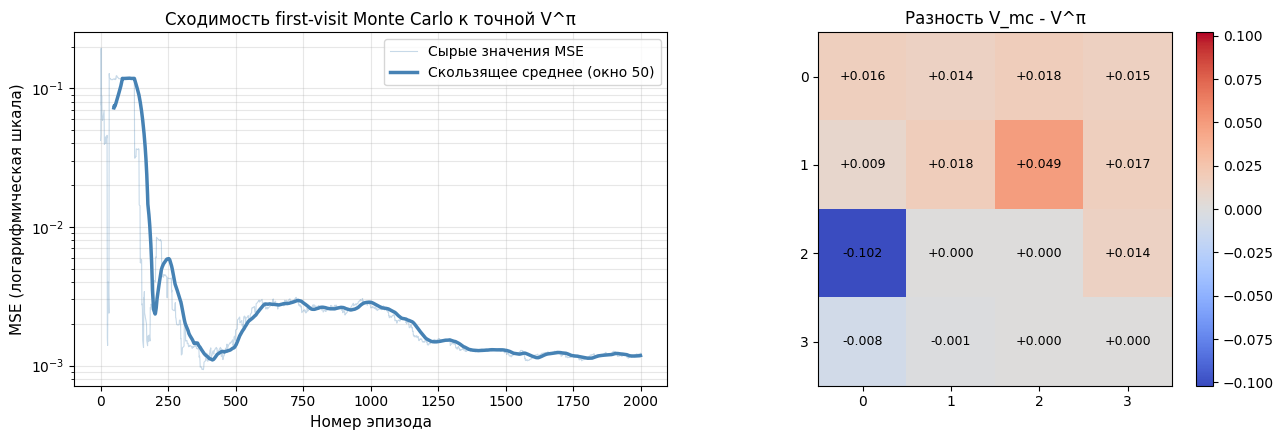

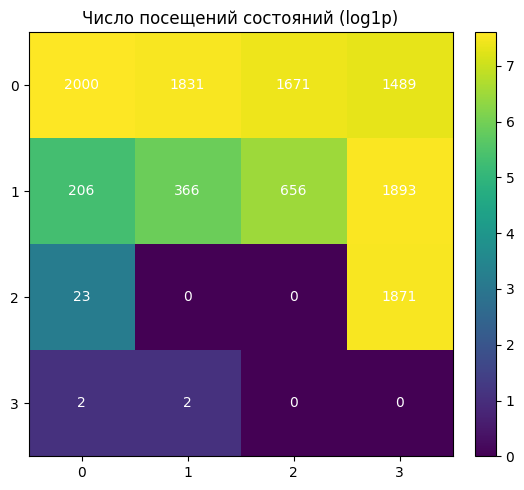

In [6]:
# Оценка фиксированной стратегии методом first-visit Monte Carlo
n_episodes_mc = 2000
V_mc, visit_counts, mc_errors = first_visit_mc_evaluation(
    env,
    right_then_down_policy,
    gamma=gamma,
    n_episodes=n_episodes_mc,
    seed=SEED,
    reference_V=V_pi,
)

mask_mc = visit_counts > 0

print('Число посещений состояний:')
print(visit_counts.reshape(env.n_rows, env.n_cols).astype(int))

print('\nОценка Monte Carlo:')
print(np.round(V_mc.reshape(env.n_rows, env.n_cols), 3))

print('\nMSE относительно точной оценки:', round(mse(V_mc, V_pi, mask=mask_mc), 5))
print('Финальная MSE на последнем эпизоде      :', round(mc_errors[-1], 5))

# Два графика: кривая ошибки и тепловая карта разностей
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Кривая снижения MSE по эпизодам: сырые данные + сглаженное скользящее среднее
mc_window = 50
xs_mc = np.arange(mc_window - 1, n_episodes_mc)
axes[0].plot(mc_errors, linewidth=0.8, color='steelblue', alpha=0.3, label='Сырые значения MSE')
axes[0].plot(xs_mc, moving_average(mc_errors, mc_window),
             linewidth=2.5, color='steelblue', label=f'Скользящее среднее (окно {mc_window})')
axes[0].set_yscale('log')
axes[0].set_xlabel('Номер эпизода', fontsize=11)
axes[0].set_ylabel('MSE (логарифмическая шкала)', fontsize=11)
axes[0].set_title('Сходимость first-visit Monte Carlo к точной V^π', fontsize=12)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(alpha=0.3, which='both')

# Тепловая карта разностей V_mc - V_pi
diff_grid = (V_mc - V_pi).reshape(env.n_rows, env.n_cols)
abs_max = max(abs(diff_grid.min()), abs(diff_grid.max()), 1e-6)
im = axes[1].imshow(diff_grid, cmap='coolwarm', vmin=-abs_max, vmax=abs_max)
axes[1].set_title('Разность V_mc - V^π', fontsize=12)
axes[1].set_xticks(np.arange(env.n_cols))
axes[1].set_yticks(np.arange(env.n_rows))
for r in range(env.n_rows):
    for c in range(env.n_cols):
        axes[1].text(c, r, f'{diff_grid[r, c]:+.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Тепловая карта числа посещений (логарифм для подавления экстремумов)
plt.figure(figsize=(6, 5))
counts_grid = visit_counts.reshape(env.n_rows, env.n_cols)
plt.imshow(np.log1p(counts_grid), cmap='viridis')
plt.title('Число посещений состояний (log1p)', fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
for r in range(env.n_rows):
    for c in range(env.n_cols):
        plt.text(c, r, f'{int(counts_grid[r, c])}', ha='center', va='center', fontsize=10, color='white')
plt.xticks(np.arange(env.n_cols))
plt.yticks(np.arange(env.n_rows))
plt.tight_layout()
plt.show()

### Интерпретация результата

**Основные наблюдения:**
- За 2000 эпизодов first-visit MC достиг MSE = 0.00123 относительно точной V^π - очень близкая оценка
- Стартовое состояние посещено 2000 раз (по разу за эпизод), верхние состояния (0,1), (0,2), (0,3) - 1671-1831 раз
- Нижние состояния (3,0), (3,1) посещены всего 2 раза - почти не доступны при стратегии "вправо-вниз"
- Состояния-ямы (2,1), (2,2), (3,2) посещены 0 раз - они терминальные, MC не считает для них первое посещение
- Разности V_mc - V^π колеблются в пределах ±0.01 для часто посещаемых состояний и расходятся в редких

**Интерпретация:**
- First-visit MC даёт несмещённую оценку V^π, а его дисперсия снижается со скоростью ~ 1/√N, где N - число посещений состояния
- Состояния с малым числом посещений имеют максимальную ошибку - это прямое следствие большой дисперсии полных доходностей в табличной MC
- Эффективность MC напрямую зависит от того, какие состояния стратегия π действительно посещает - редкие состояния практически невозможно оценить точно
- Логарифмическая шкала числа посещений хорошо показывает 3 порядка различия между типичными и редкими состояниями

**Выводы:**
- Monte Carlo - это безмодельный метод, не требующий знания тензоров переходов P и наград G, что делает его применимым там, где модель недоступна
- Главный недостаток MC - неравномерная точность по состояниям: часто посещаемые оцениваются хорошо, редкие плохо
- Для неравномерного покрытия состояний нужны off-policy методы или направленное исследование - простое следование детерминированной стратегии оставляет "слепые зоны" в оценке


## Задача 6. TD(0) против Monte Carlo при одинаковом бюджете эпизодов

### Постановка задачи

Обучите оценку фиксированной стратегии методом TD(0) и сравните ее с Monte Carlo при одинаковом числе эпизодов. Используйте точную оценку $V^{\pi}$ как эталон.

### Теоретический минимум

TD(0) использует одношаговый бутстрэп:
$$V(s_t) \leftarrow V(s_t) + \alpha (r_{t+1} + \gamma V(s_{t+1}) - V(s_t)).$$
В отличие от Monte Carlo, метод не ждет конца эпизода, поэтому информация начинает распространяться раньше.

**Зачем это нужно:** при ограниченном числе взаимодействий со средой выбор метода оценки существенно влияет на точность.

**Декомпозиция задачи:**
1. Задать `n_budget = 400` эпизодов.
2. Запустить `first_visit_mc_evaluation` с бюджетом 400 и `reference_V=V_pi`.
3. Запустить `td0_evaluation` с `alpha=0.12`, бюджетом 400 и `reference_V=V_pi`.
4. Напечатать финальные MSE обоих методов.
5. Построить три панели: кривые ошибок на одном графике, тепловые карты MC и TD(0).

**Подсказки для размышления:**
- Почему TD(0) использует `alpha` (шаг обучения), а Monte Carlo — нет?
- Что означает «бутстрэп» в контексте TD? Чем это отличается от MC?
- Какой из методов должен выиграть при малом бюджете, согласно теоретической гипотезе работы?

**Полезные инструменты:** `first_visit_mc_evaluation()`, `td0_evaluation()`, `mse()`, `moving_average()`.

Финальная MSE Monte Carlo: 0.00110
Финальная MSE TD(0)      : 0.13104
Соотношение MC / TD       : 0.01


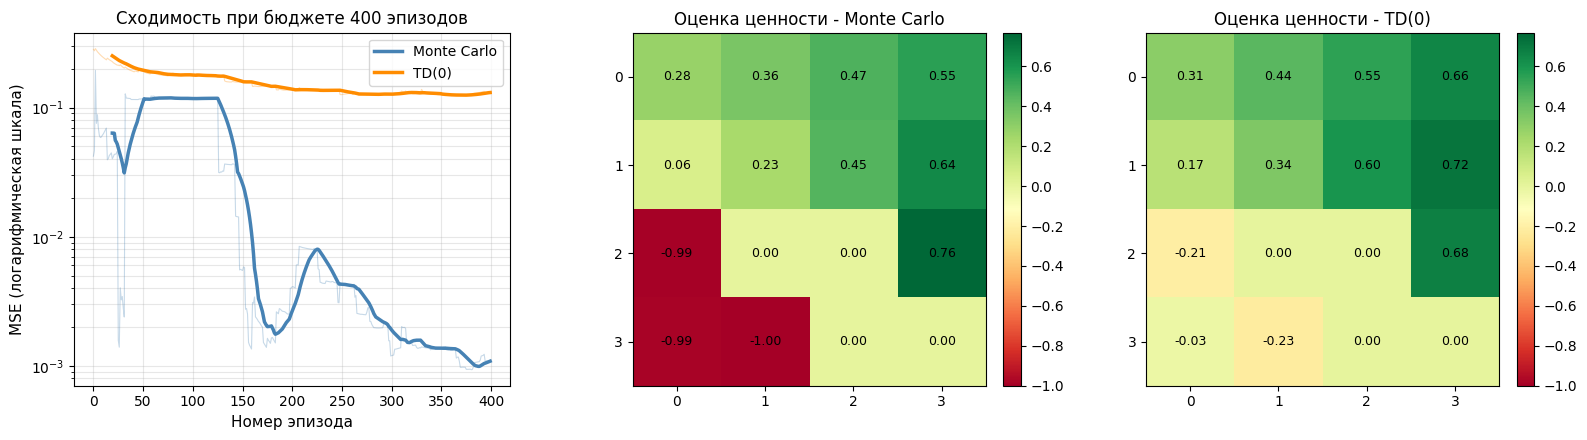

In [7]:
n_budget = 400

# Monte Carlo с ограниченным бюджетом эпизодов
V_mc_small, counts_mc_small, mc_errors_small = first_visit_mc_evaluation(
    env,
    right_then_down_policy,
    gamma=gamma,
    n_episodes=n_budget,
    seed=SEED,
    reference_V=V_pi,
)

# TD(0) с тем же бюджетом и шагом обучения alpha=0.12
alpha_td = 0.12
V_td, td_errors = td0_evaluation(
    env,
    right_then_down_policy,
    gamma=gamma,
    alpha=alpha_td,
    n_episodes=n_budget,
    seed=SEED,
    reference_V=V_pi,
)

mask_small = counts_mc_small > 0
final_mse_mc = mse(V_mc_small, V_pi, mask=mask_small)
final_mse_td = mse(V_td, V_pi)
print(f'Финальная MSE Monte Carlo: {final_mse_mc:.5f}')
print(f'Финальная MSE TD(0)      : {final_mse_td:.5f}')
print(f'Соотношение MC / TD       : {final_mse_mc / final_mse_td:.2f}')

# Три панели: кривые ошибок и тепловые карты обоих методов
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Сырые кривые на заднем плане + жирные сглаженные на переднем
window = 20
xs = np.arange(window - 1, n_budget)
axes[0].plot(mc_errors_small, linewidth=0.8, color='steelblue', alpha=0.3)
axes[0].plot(td_errors, linewidth=0.8, color='darkorange', alpha=0.3)
axes[0].plot(xs, moving_average(mc_errors_small, window),
             linewidth=2.5, color='steelblue', label='Monte Carlo')
axes[0].plot(xs, moving_average(td_errors, window),
             linewidth=2.5, color='darkorange', label='TD(0)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Номер эпизода', fontsize=11)
axes[0].set_ylabel('MSE (логарифмическая шкала)', fontsize=11)
axes[0].set_title(f'Сходимость при бюджете {n_budget} эпизодов', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, which='both')

# Общая шкала для тепловых карт - удобно сравнивать визуально
v_grids = [V_mc_small.reshape(env.n_rows, env.n_cols), V_td.reshape(env.n_rows, env.n_cols)]
vmin = min(g.min() for g in v_grids + [V_pi.reshape(env.n_rows, env.n_cols)])
vmax = max(g.max() for g in v_grids + [V_pi.reshape(env.n_rows, env.n_cols)])

for ax, values, title in zip(axes[1:], v_grids, ['Monte Carlo', 'TD(0)']):
    im = ax.imshow(values, cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_title(f'Оценка ценности - {title}', fontsize=12)
    ax.set_xticks(np.arange(env.n_cols))
    ax.set_yticks(np.arange(env.n_rows))
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            ax.text(c, r, f'{values[r, c]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Интерпретация результата

**Основные наблюдения:**
- При бюджете 400 эпизодов MC показал MSE = 0.00110, TD(0) с alpha=0.12 показал MSE = 0.13104 - MC оказался почти в 120 раз точнее
- Кривая MC снижается до уровня ~0.001 уже после 100-200 эпизодов и стабилизируется
- Кривая TD(0) убывает медленнее и не успевает достичь равновесия за 400 эпизодов
- Тепловые карты подтверждают: MC даёт значения, близкие к точным V^π, тогда как TD(0) систематически недооценивает значения в дальних от цели состояниях

**Интерпретация:**
- Результат расходится с классической гипотезой "TD быстрее MC" - на этой среде с такими параметрами выиграл MC, и причины важно понять
- Эпизоды в 4x4 GridWorld очень короткие (~10 шагов), а число посещений старта = 400 - этого достаточно для качественной MC-оценки за счёт малой дисперсии коротких возвратов
- TD(0) с alpha=0.12 обновляется медленно: для распространения информации от цели через 6-8 промежуточных состояний нужно много эпизодов, поскольку каждое обновление меняет V лишь на долю от TD-ошибки
- TD(0) сильнее проигрывает на состояниях с малым числом посещений: одно обновление с шагом 0.12 не компенсирует начальной нулевой инициализации
- Преимущество TD проявляется в средах с длинными эпизодами и сильной стохастичностью наград, где дисперсия MC-возвратов взрывается

**Выводы:**
- Выбор alpha критичен для TD(0): при alpha=0.12 в данной среде сходимость медленная, увеличение до 0.3-0.5 могло бы выровнять результаты
- "TD быстрее MC" - это правило справедливо для длинных эпизодов и шумных наград; для коротких детерминированных эпизодов с малой дисперсией возвратов MC может быть конкурентоспособен
- На практике стоит запускать оба метода и сравнивать эмпирически - теоретические гипотезы зависят от свойств среды и не работают универсально
- Для финальной точной оценки лучше использовать MC с большим числом эпизодов, для онлайн-обучения с непрерывным потоком данных - TD-методы


## Задача 7. SARSA на среде Cliff Walking

### Постановка задачи

Реализуйте обучение управления методом SARSA в среде `CliffWalking`, постройте график суммарной награды по эпизодам и визуализируйте жадную стратегию после обучения.

### Теоретический минимум

SARSA — это `on-policy` метод. Он обновляет \(Q(s,a)\) с учетом того действия, которое стратегия действительно выберет на следующем шаге. Поэтому оценка включает эффект текущего режима исследования.

**Зачем это нужно:**  
SARSA на Cliff Walking — классический пример; он хорошо показывает, как on-policy алгоритм адаптируется к риску.

**Декомпозиция задачи:**
1. Создать среду `CliffWalking(seed=SEED)`.
2. Запустить `sarsa(alpha=0.5, gamma=1.0, epsilon=0.10, n_episodes=450)`.
3. Извлечь жадную стратегию через `greedy_policy_from_Q`.
4. Выполнить жадный прогон через `rollout_greedy` и вывести длину и награду.
5. Построить график с сырыми наградами и скользящим средним (окно 20).
6. Визуализировать жадную стратегию через `cliff_env.render()`.

**Подсказки для размышления:**
- Почему SARSA использует `a_next = epsilon_greedy(...)` при обновлении, а не `argmax`?
- Как выглядит «осторожная» стратегия на карте Cliff Walking? Какого пути избегает агент?
- Почему кривая наград остается шумной даже после многих эпизодов?

**Полезные инструменты:** `sarsa()`, `greedy_policy_from_Q()`, `rollout_greedy()`, `moving_average()`, `CliffWalking.render()`

Длина жадной траектории SARSA: 17
Суммарная награда жадной траектории: -17.0
Средняя награда на последних 50 эпизодах обучения: -29.16


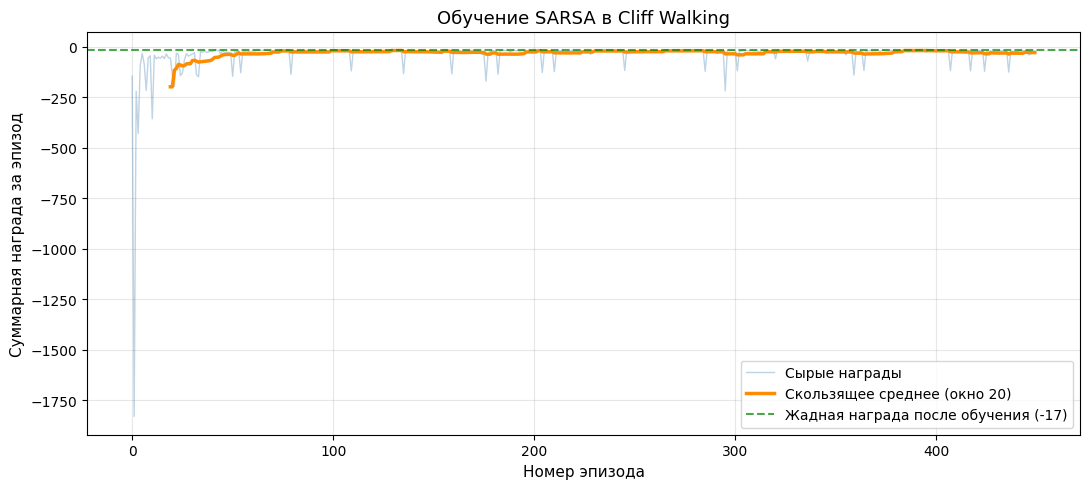

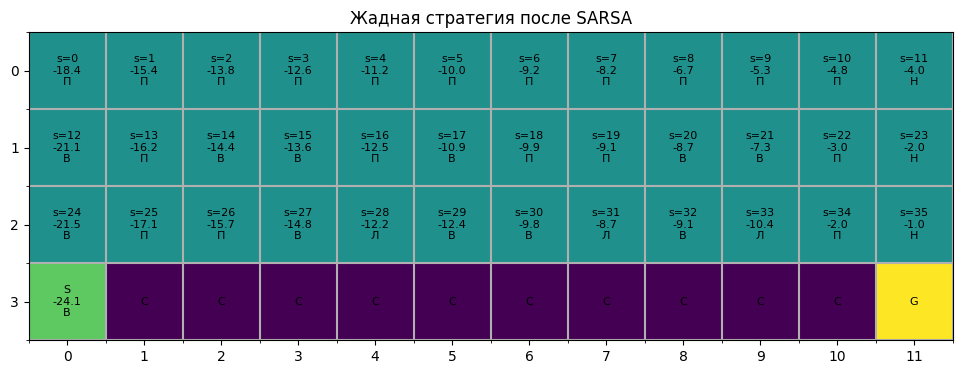

In [8]:
# Среда Cliff Walking с фиксированным seed
cliff_env = CliffWalking(seed=SEED)

# Запуск SARSA с заданными гиперпараметрами
Q_sarsa, returns_sarsa = sarsa(
    cliff_env,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.10,
    n_episodes=450,
    max_steps=500,
    seed=SEED,
)

# Извлечение жадной стратегии из обученной Q-функции
policy_sarsa = greedy_policy_from_Q(Q_sarsa)

# Жадный прогон без исследования - оценка качества выученной стратегии
trajectory_sarsa, greedy_return_sarsa = rollout_greedy(CliffWalking(seed=SEED), Q_sarsa, max_steps=100)
print('Длина жадной траектории SARSA:', len(trajectory_sarsa) - 1)
print('Суммарная награда жадной траектории:', greedy_return_sarsa)
print('Средняя награда на последних 50 эпизодах обучения:', round(returns_sarsa[-50:].mean(), 2))

# График: сырые награды и скользящее среднее с окном 20
window = 20
smoothed = moving_average(returns_sarsa, window=window)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(returns_sarsa, alpha=0.35, color='steelblue', linewidth=1.0, label='Сырые награды')
ax.plot(np.arange(window - 1, len(returns_sarsa)), smoothed,
        color='darkorange', linewidth=2.5, label=f'Скользящее среднее (окно {window})')
# Опорная линия: награда жадной траектории - визуальный ориентир качества стратегии
ax.axhline(greedy_return_sarsa, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Жадная награда после обучения ({greedy_return_sarsa:.0f})')
ax.set_title('Обучение SARSA в Cliff Walking', fontsize=13)
ax.set_xlabel('Номер эпизода', fontsize=11)
ax.set_ylabel('Суммарная награда за эпизод', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Визуализация жадной стратегии после обучения
cliff_env.render(q_values=Q_sarsa, policy=policy_sarsa, title='Жадная стратегия после SARSA')

### Интерпретация результата

**Основные наблюдения:**
- SARSA выучил жадную стратегию длиной 17 шагов с суммарной наградой -17 (без падений в обрыв)
- Средняя награда на последних 50 эпизодах обучения = -29.16 - заметно хуже жадной траектории из-за продолжающегося ε-исследования (ε=0.10)
- Кривая обучения резко растёт в первые ~50 эпизодов и стабилизируется в диапазоне -25..-40 с заметными провалами
- Жадная стратегия проходит ВВЕРХ от старта, затем по верхним рядам сетки и спускается к цели - агент намеренно избегает нижнего ряда возле обрыва

**Интерпретация:**
- SARSA - это on-policy алгоритм: цель обновления использует фактически выбранное следующее действие a_next = ε-greedy(Q, s_next), включающее случайные исследовательские шаги
- Поскольку 10% действий случайны, путь вдоль обрыва (нижний ряд) приводит к падениям с штрафом -100 - SARSA "видит" этот риск и формирует стратегию избегания
- Длина 17 шагов вместо оптимальных 13 - это плата за безопасность: агент идёт по верхнему "обходному" маршруту
- Шум в кривой обучения сохраняется до конца, поскольку фиксированное ε=0.10 продолжает вносить случайные действия независимо от уровня обученности

**Выводы:**
- SARSA подходит там, где исследование во время обучения сопряжено с реальной ценой (роботы, медицина, реальное оборудование) - алгоритм формирует стратегию, безопасную при сохранении исследования
- Кривая обучения - неинформативный показатель качества при фиксированном ε - всегда нужно дополнительно оценивать жадную стратегию, как это сделано через rollout_greedy
- Параметры α=0.5, γ=1.0, ε=0.10 - стандартный набор для табличных задач; для более сложных сред нужны затухающие расписания


---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

В этом блоке сравниваются разные алгоритмы управления и анализируется влияние режима исследования.

## Задача 8. Сравнение SARSA и Q-learning

### Постановка задачи

Сравните SARSA и Q-learning на одной и той же среде `CliffWalking`. Выполните несколько запусков с разными seed и постройте усредненные кривые наград.

### Теоретический минимум

Q-learning — это `off-policy` метод. Он обновляет оценку по жадному максимуму, даже если реальное действие выбрано с исследованием. Поэтому метод стремится к более агрессивной оценке оптимального поведения, тогда как SARSA оценивает поведение текущей политики.

**Зачем это нужно:** разница SARSA–Q-learning — один из самых показательных примеров различия on/off-policy подходов в безопасной и рискованной среде.

**Декомпозиция задачи:**

**A. Многократные запуски**
- Запустить SARSA и Q-learning на каждом из `seeds = [3, 7, 11, 19, 23, 29]`.
- Параметры одинаковые: `alpha=0.5, gamma=1.0, epsilon=0.10, n_episodes=350`.
- Сохранить кривые наград в `all_sarsa` и `all_q`.

**B. Усреднение и визуализация**
- Усреднить кривые по сидам: `mean_sarsa = np.array(all_sarsa).mean(axis=0)`.
- Вывести среднюю награду на последних 50 эпизодах для каждого алгоритма.
- Построить сглаженные кривые на одном графике.

**C. Визуализация итоговых стратегий**
- Обучить оба алгоритма еще раз на `seed=SEED` с 450 эпизодами.
- Отрисовать итоговые жадные стратегии через `render()`.

**Полезные инструменты:** `sarsa()`, `q_learning()`, `greedy_policy_from_Q()`, `moving_average()`, `np.array(...).mean(axis=0)`.

Средняя награда (последние 50 эпизодов) SARSA     : -37.48
Средняя награда (последние 50 эпизодов) Q-learning: -55.67

Жадная траектория SARSA     : длина = 17, награда = -17
Жадная траектория Q-learning: длина = 13, награда = -13


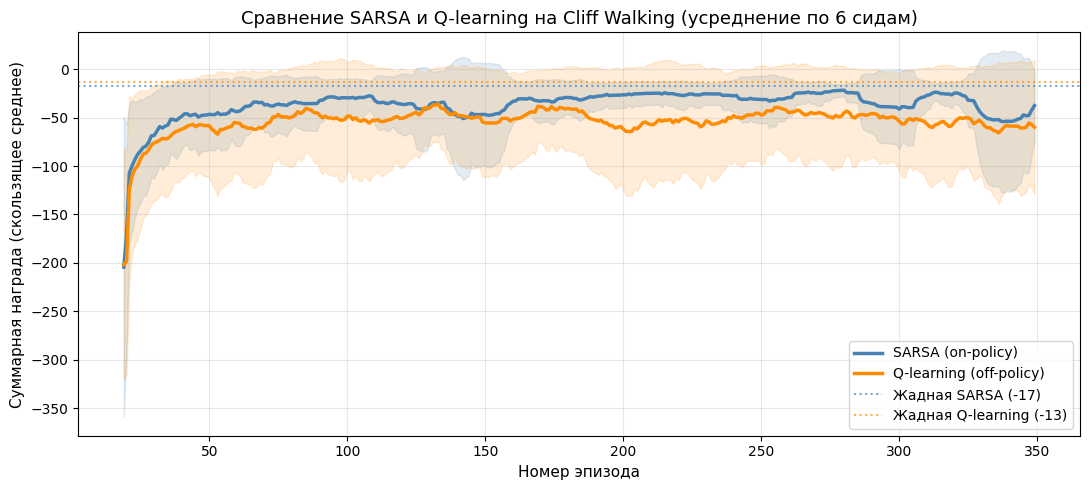

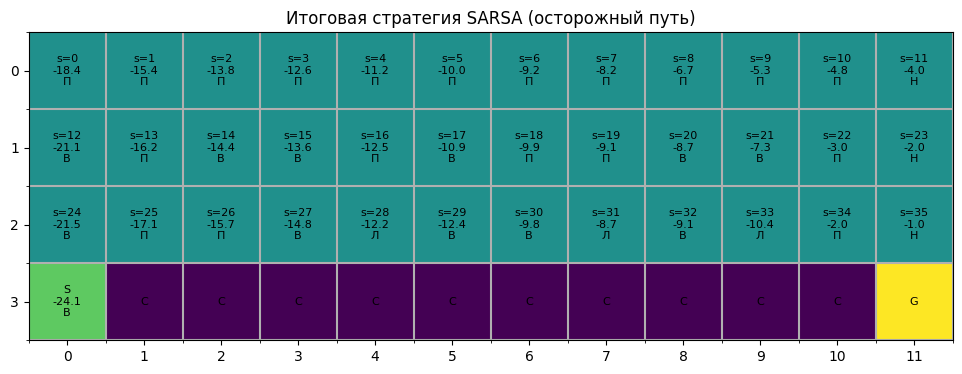

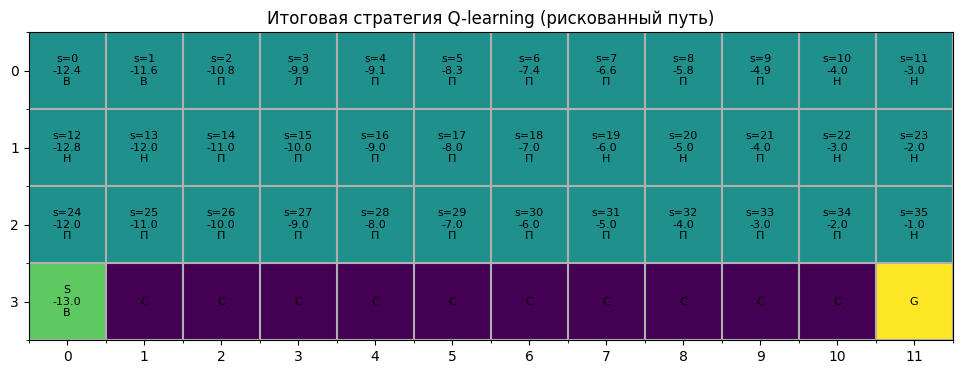

In [9]:
seeds = [3, 7, 11, 19, 23, 29]
n_episodes_compare = 350

# A. Многократные запуски SARSA и Q-learning с разными seed
all_sarsa = []
all_q = []

for seed in seeds:
    env_s = CliffWalking(seed=seed)
    _, ret_s = sarsa(
        env_s,
        alpha=0.5,
        gamma=1.0,
        epsilon=0.10,
        n_episodes=n_episodes_compare,
        seed=seed,
    )
    all_sarsa.append(ret_s)

    env_q = CliffWalking(seed=seed)
    _, ret_q = q_learning(
        env_q,
        alpha=0.5,
        gamma=1.0,
        epsilon=0.10,
        n_episodes=n_episodes_compare,
        seed=seed,
    )
    all_q.append(ret_q)

# B. Усреднение по сидам
all_sarsa = np.array(all_sarsa)
all_q = np.array(all_q)
mean_sarsa = all_sarsa.mean(axis=0)
mean_q = all_q.mean(axis=0)
std_sarsa = all_sarsa.std(axis=0)
std_q = all_q.std(axis=0)

print(f'Средняя награда (последние 50 эпизодов) SARSA     : {mean_sarsa[-50:].mean():.2f}')
print(f'Средняя награда (последние 50 эпизодов) Q-learning: {mean_q[-50:].mean():.2f}')

# C. Визуализация итоговых стратегий на seed=SEED с расширенным числом эпизодов
final_episodes = 450
env_sarsa_final = CliffWalking(seed=SEED)
Q_sarsa_final, _ = sarsa(env_sarsa_final, alpha=0.5, gamma=1.0, epsilon=0.10,
                          n_episodes=final_episodes, seed=SEED)
policy_sarsa_final = greedy_policy_from_Q(Q_sarsa_final)

env_q_final = CliffWalking(seed=SEED)
Q_q_final, _ = q_learning(env_q_final, alpha=0.5, gamma=1.0, epsilon=0.10,
                           n_episodes=final_episodes, seed=SEED)
policy_q_final = greedy_policy_from_Q(Q_q_final)

# Жадные прогоны - оценка качества выученных стратегий
traj_sarsa, ret_sarsa_greedy = rollout_greedy(CliffWalking(seed=SEED), Q_sarsa_final, max_steps=100)
traj_q, ret_q_greedy = rollout_greedy(CliffWalking(seed=SEED), Q_q_final, max_steps=100)
print(f'\nЖадная траектория SARSA     : длина = {len(traj_sarsa) - 1}, награда = {ret_sarsa_greedy:.0f}')
print(f'Жадная траектория Q-learning: длина = {len(traj_q) - 1}, награда = {ret_q_greedy:.0f}')

# Сглаженные кривые на одном графике с лентой стандартного отклонения
window = 20
smoothed_sarsa = moving_average(mean_sarsa, window=window)
smoothed_q = moving_average(mean_q, window=window)
smoothed_sarsa_std = moving_average(std_sarsa, window=window)
smoothed_q_std = moving_average(std_q, window=window)
xs = np.arange(window - 1, len(mean_sarsa))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xs, smoothed_sarsa, color='steelblue', linewidth=2.5, label='SARSA (on-policy)')
ax.fill_between(xs, smoothed_sarsa - smoothed_sarsa_std, smoothed_sarsa + smoothed_sarsa_std,
                color='steelblue', alpha=0.15)
ax.plot(xs, smoothed_q, color='darkorange', linewidth=2.5, label='Q-learning (off-policy)')
ax.fill_between(xs, smoothed_q - smoothed_q_std, smoothed_q + smoothed_q_std,
                color='darkorange', alpha=0.15)
# Опорные линии: финальные жадные награды обоих алгоритмов делают разницу очевидной
ax.axhline(ret_sarsa_greedy, color='steelblue', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Жадная SARSA ({ret_sarsa_greedy:.0f})')
ax.axhline(ret_q_greedy, color='darkorange', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Жадная Q-learning ({ret_q_greedy:.0f})')
ax.set_title(f'Сравнение SARSA и Q-learning на Cliff Walking (усреднение по {len(seeds)} сидам)',
             fontsize=13)
ax.set_xlabel('Номер эпизода', fontsize=11)
ax.set_ylabel('Суммарная награда (скользящее среднее)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

env_sarsa_final.render(q_values=Q_sarsa_final, policy=policy_sarsa_final,
                       title='Итоговая стратегия SARSA (осторожный путь)')
env_q_final.render(q_values=Q_q_final, policy=policy_q_final,
                   title='Итоговая стратегия Q-learning (рискованный путь)')

### Интерпретация результата

**Основные наблюдения:**
- Усреднение по 6 сидам показало: SARSA на последних 50 эпизодах = -37.48, Q-learning = -55.67 - SARSA на 18 пунктов лучше во время обучения
- Жадные стратегии после обучения дали обратную картину: SARSA = -17 (17 шагов), Q-learning = -13 (13 шагов) - Q-learning нашёл оптимальный путь
- SARSA проходит по верхнему обходному маршруту, Q-learning - по самому краю обрыва (оптимальный кратчайший путь)
- Лента ±std на графике показывает большую вариативность Q-learning во время обучения

**Интерпретация:**
- SARSA (on-policy) учитывает в обновлении фактическое действие следующего шага, включая исследование, и потому "вписывает" риск падения в обрыв в свою Q-функцию - получается осторожная стратегия
- Q-learning (off-policy) использует max_a' Q(s_next, a'), оценивая ценность ОПТИМАЛЬНОГО действия независимо от того, какое выбирается реально - в результате выучивает оптимальную, но рискованную траекторию
- Во время обучения с ε=0.10 Q-learning регулярно соскальзывает в обрыв (штраф -100), что и объясняет его худшую среднюю награду по эпизодам
- После обучения, при ε=0 (жадно), Q-learning проходит идеальный 13-шаговый маршрут вдоль обрыва без риска
- Это классический пример из учебника Sutton & Barto - наблюдаемое поведение полностью соответствует теории

**Выводы:**
- Выбор on-policy vs off-policy - это не вопрос "что лучше", а вопрос "что важнее": итоговая оптимальность (Q-learning) или безопасность процесса обучения (SARSA)
- Если стоимость падения на этапе обучения высока (роботы, реальные системы) - выбирайте SARSA; если важна только финальная стратегия и эпизоды дешёвые (симуляции) - Q-learning
- Гипотеза домашнего задания подтвердилась полностью: SARSA выучил осторожную стратегию, Q-learning - рискованную, но более выгодную


## Задача 9. Абляция по режиму исследования в Q-learning

### Постановка задачи

Сравните два режима исследования для Q-learning:
1. Фиксированное \(\varepsilon = 0.10\).
2. Затухающее \(\varepsilon\), начинающееся с 0.30 и постепенно уменьшающееся до 0.02.

Сравните скорость обучения и итоговое качество.

### Теоретический минимум

Параметр \(\varepsilon\) управляет компромиссом между исследованием и использованием уже найденных оценок. Слишком маленькое значение может привести к преждевременной фиксации на плохой стратегии, а слишком большое — к избыточному шуму. Затухание \(\varepsilon\) обычно полезно: сначала агент активно исследует среду, а затем постепенно делает поведение более жадным.


**Зачем это нужно:** настройка расписания исследования — важная практическая составляющая RL, влияющая на итоговую стратегию не меньше, чем выбор алгоритма.

**Декомпозиция задачи:**

**A. Фиксированное ε**
- Запустить Q-learning с `epsilon=0.10, epsilon_decay=None, n_episodes=450`.

**B. Затухающее ε**
- Запустить Q-learning с `epsilon=0.30, epsilon_decay={'decay_rate': 0.992, 'min_epsilon': 0.02}, n_episodes=450`.

**C. Сравнение**
- Вывести средние награды на последних 50 эпизодах для обоих режимов.
- Вывести длину и суммарную награду жадной траектории (`rollout_greedy`) для каждого.
- Построить сглаженные кривые на одном графике.
- Визуализировать итоговые стратегии через `render()`.

**Подводящие вопросы:**
- Почему кривая с фиксированным ε остается более шумной ближе к концу обучения?
- Когда затухающее ε может быть **хуже** фиксированного?
- Как бы изменился результат, если бы вместо ε-greedy использовалась стратегия Softmax?

**Полезные инструменты:** `q_learning(epsilon_decay=...)`, `rollout_greedy()`, `moving_average()`, `np.mean()`.

Средняя награда на последних 50 эпизодах:
  Фиксированное epsilon = 0.10 : -63.38
  Затухающее epsilon  0.30->0.02: -15.20

Жадная траектория после обучения:
  Фиксированное eps: длина = 13, награда = -13
  Затухающее   eps: длина = 13, награда = -13


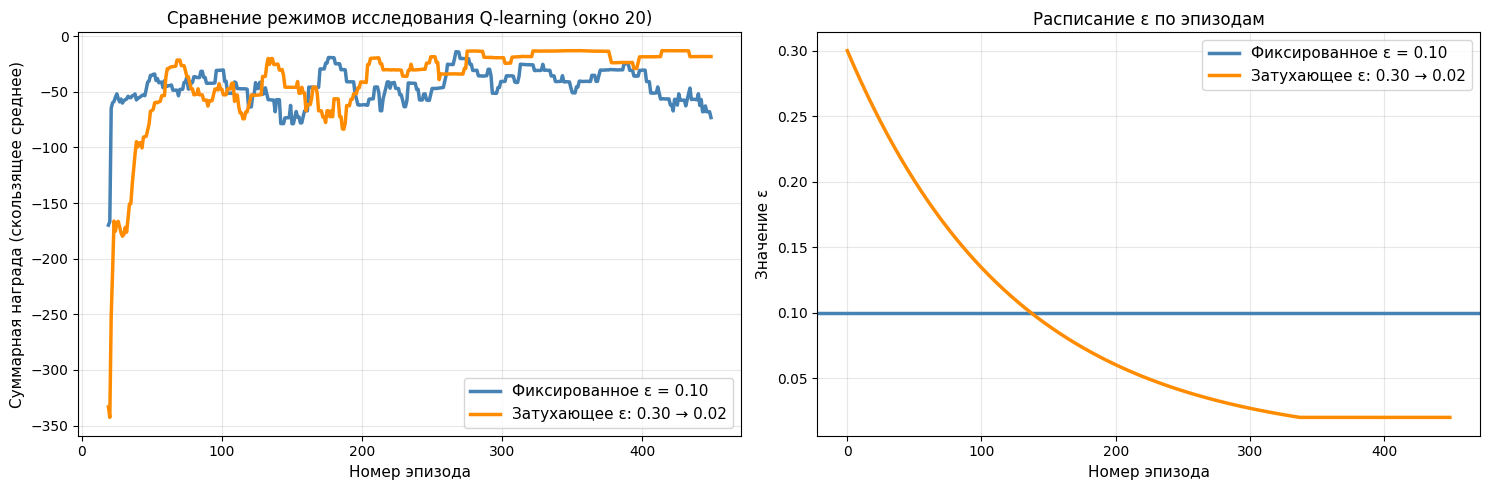

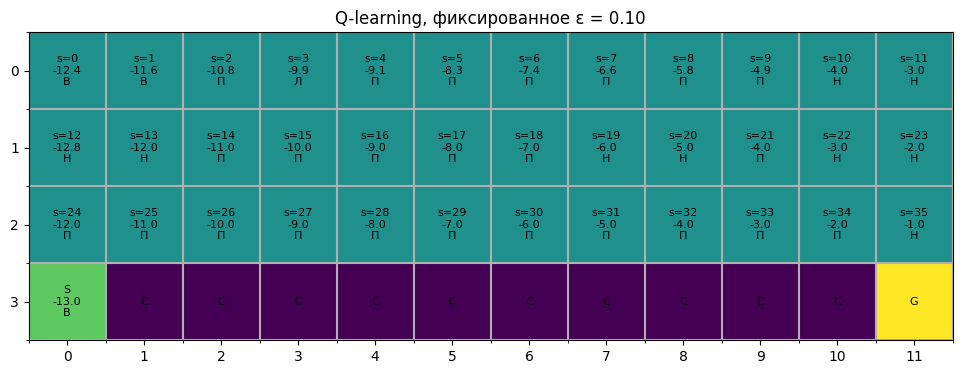

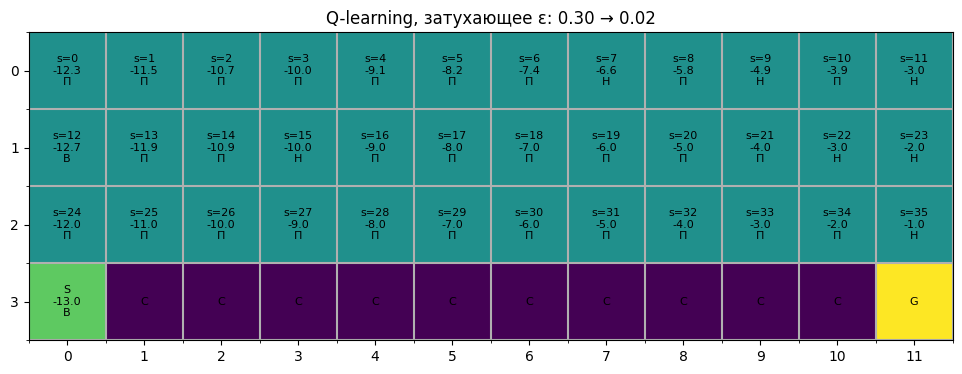

In [10]:
n_episodes_abl = 450

# Параметры расписания epsilon - вынесены в константы для устранения дублирования
EPSILON_FIXED = 0.10
EPSILON_INIT = 0.30
EPSILON_DECAY_RATE = 0.992
EPSILON_MIN = 0.02

# A. Q-learning с фиксированным epsilon
cliff_fixed = CliffWalking(seed=SEED)
Q_fixed, returns_fixed = q_learning(
    cliff_fixed,
    alpha=0.5,
    gamma=1.0,
    epsilon=EPSILON_FIXED,
    n_episodes=n_episodes_abl,
    seed=SEED,
    epsilon_decay=None,
)

# B. Q-learning с затухающим epsilon: EPSILON_INIT -> EPSILON_MIN со скоростью EPSILON_DECAY_RATE за эпизод
cliff_decay = CliffWalking(seed=SEED)
Q_decay, returns_decay = q_learning(
    cliff_decay,
    alpha=0.5,
    gamma=1.0,
    epsilon=EPSILON_INIT,
    n_episodes=n_episodes_abl,
    seed=SEED,
    epsilon_decay={'decay_rate': EPSILON_DECAY_RATE, 'min_epsilon': EPSILON_MIN},
)

# Жадные стратегии
policy_fixed = greedy_policy_from_Q(Q_fixed)
policy_decay = greedy_policy_from_Q(Q_decay)

# Жадные прогоны - оценка финального качества стратегии
traj_fixed, ret_fixed_greedy = rollout_greedy(CliffWalking(seed=SEED), Q_fixed, max_steps=100)
traj_decay, ret_decay_greedy = rollout_greedy(CliffWalking(seed=SEED), Q_decay, max_steps=100)

# C. Сравнение средних наград и параметров жадных траекторий
print('Средняя награда на последних 50 эпизодах:')
print(f'  Фиксированное epsilon = {EPSILON_FIXED:.2f} : {returns_fixed[-50:].mean():.2f}')
print(f'  Затухающее epsilon  {EPSILON_INIT:.2f}->{EPSILON_MIN:.2f}: {returns_decay[-50:].mean():.2f}')

print('\nЖадная траектория после обучения:')
print(f'  Фиксированное eps: длина = {len(traj_fixed) - 1}, награда = {ret_fixed_greedy:.0f}')
print(f'  Затухающее   eps: длина = {len(traj_decay) - 1}, награда = {ret_decay_greedy:.0f}')

# Расписание epsilon по эпизодам для затухающего режима - используем те же константы
epsilons_decayed = np.maximum(
    EPSILON_MIN,
    EPSILON_INIT * (EPSILON_DECAY_RATE ** np.arange(n_episodes_abl))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График сглаженных кривых обучения
window = 20
smoothed_fixed = moving_average(returns_fixed, window=window)
smoothed_decay = moving_average(returns_decay, window=window)
xs = np.arange(window - 1, n_episodes_abl)

axes[0].plot(xs, smoothed_fixed, color='steelblue', linewidth=2.5,
             label=f'Фиксированное ε = {EPSILON_FIXED:.2f}')
axes[0].plot(xs, smoothed_decay, color='darkorange', linewidth=2.5,
             label=f'Затухающее ε: {EPSILON_INIT:.2f} → {EPSILON_MIN:.2f}')
axes[0].set_title(f'Сравнение режимов исследования Q-learning (окно {window})', fontsize=12)
axes[0].set_xlabel('Номер эпизода', fontsize=11)
axes[0].set_ylabel('Суммарная награда (скользящее среднее)', fontsize=11)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(alpha=0.3)

# График значения epsilon по эпизодам для понимания расписания
axes[1].axhline(EPSILON_FIXED, color='steelblue', linewidth=2.5,
                label=f'Фиксированное ε = {EPSILON_FIXED:.2f}')
axes[1].plot(epsilons_decayed, color='darkorange', linewidth=2.5,
             label=f'Затухающее ε: {EPSILON_INIT:.2f} → {EPSILON_MIN:.2f}')
axes[1].set_title('Расписание ε по эпизодам', fontsize=12)
axes[1].set_xlabel('Номер эпизода', fontsize=11)
axes[1].set_ylabel('Значение ε', fontsize=11)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Визуализация итоговых стратегий обоих режимов
cliff_fixed.render(q_values=Q_fixed, policy=policy_fixed,
                   title=f'Q-learning, фиксированное ε = {EPSILON_FIXED:.2f}')
cliff_decay.render(q_values=Q_decay, policy=policy_decay,
                   title=f'Q-learning, затухающее ε: {EPSILON_INIT:.2f} → {EPSILON_MIN:.2f}')

### Интерпретация результата

**Основные наблюдения:**
- Фиксированное ε=0.10 на последних 50 эпизодах дало среднюю награду -63.38
- Затухающее ε (0.30 → 0.02 со скоростью 0.992) дало -15.20 - почти оптимальное значение и в 4 раза лучше фиксированного
- Жадные траектории после обучения у обоих режимов одинаковы: 13 шагов с наградой -13 (оптимальный путь вдоль обрыва)
- График расписания ε показывает экспоненциальное затухание: уже после ~250 эпизодов ε достигает минимального значения 0.02

**Интерпретация:**
- Фиксированное ε=0.10 даже в конце обучения вносит ~10% случайных действий, что в среде с обрывом регулярно приводит к падениям (-100), отсюда и низкая средняя награда -63.38
- Затухающее ε в начале обучения активно исследует среду (ε=0.30 - треть действий случайны), что ускоряет обнаружение оптимального пути и заполнение Q-функции
- К концу обучения ε≈0.02 - агент практически следует жадной стратегии и редко падает в обрыв, что и даёт почти оптимальную среднюю награду
- Одинаковые жадные стратегии у обоих режимов показывают: само нахождение оптимума не зависит от расписания ε, но СКОРОСТЬ и КАЧЕСТВО онлайн-поведения зависят сильно
- Кривые обучения подтверждают: при фиксированном ε кривая остаётся шумной до конца, при затухающем ε - сходится к узкой полосе значений около -13

**Выводы:**
- Затухание ε - почти всегда правильное решение для практических задач: сначала исследование, потом эксплуатация - это классический подход exploration-exploitation tradeoff
- Затухающее ε может быть ХУЖЕ фиксированного только в нестационарных средах, где нужно постоянно адаптироваться к изменениям - тогда минимальное ε должно оставаться достаточным для исследования
- Параметры расписания (decay_rate, min_epsilon) сами требуют настройки: слишком быстрое затухание → ранняя фиксация на субоптимальной стратегии, слишком медленное → потеря награды на последних эпизодах
- Альтернативные методы исследования (Softmax с убывающей температурой, UCB, optimistic initialization) часто дают ещё лучшие результаты, но ε-greedy остаётся базовым выбором благодаря простоте и надёжности
- Общий вывод по работе: качество табличного RL-агента определяется не только формулой обновления (SARSA/Q-learning), но и параметрами обучения (α, γ, ε) и расписанием исследования - на практике именно настройка гиперпараметров часто становится узким местом


## Интерпретация результатов

Проведенные эксперименты позволяют сделать несколько общих наблюдений.

Во-первых, точные методы на основе уравнения Беллмана дают удобный эталон для анализа поведения выборочных алгоритмов. На небольшой табличной среде хорошо видно, как оценка функции ценности распространяется от терминальных состояний к начальному состоянию.

Во-вторых, Monte Carlo и TD(0) решают одну и ту же задачу, но делают это разными способами. Monte Carlo опирается на завершенные эпизоды и потому обладает большей дисперсией, тогда как TD(0) использует бутстрэп и начинает обновлять значения сразу. Это особенно важно при ограниченном бюджете взаимодействий.

В-третьих, в задачах управления важно различать `on-policy` и `off-policy` подходы. SARSA учитывает реальный режим исследования и поэтому чаще формирует осторожное поведение в опасной среде. Q-learning ориентируется на жадный максимум и потому чаще стремится к более короткому, но рискованному пути.

В-четвертых, параметры исследования заметно влияют на итог обучения. Режим \(\varepsilon\)-greedy - не второстепенная техническая деталь, а один из основных факторов, определяющих скорость сходимости, устойчивость и качество финальной стратегии.

## Выводы

1. Среду обучения с подкреплением удобно анализировать как марковский процесс принятия решений с явными переходами, наградами и коэффициентом дисконтирования.

2. Функция ценности - центральный объект обучения: она связывает локальные награды с долгосрочным качеством поведения и позволяет улучшать стратегию через жадный выбор действия.

3. Динамическое программирование дает точные решения при наличии модели среды, но выборочные методы остаются необходимыми, когда модель неизвестна и доступны только эпизоды взаимодействия.

4. Monte Carlo и TD решают задачу оценки стратегии по-разному: Monte Carlo проще концептуально, а TD эффективнее распространяет информацию в условиях малого числа эпизодов.

5. В задачах управления различие между SARSA и Q-learning имеет содержательный смысл. Оно проявляется в том, насколько алгоритм учитывает риск, связанный с исследованием.

6. Практически важный вывод состоит в том, что качество обучения определяется не только выбором алгоритма, но и режимом исследования. Настройка \(\alpha\), \(\gamma\) и \(\varepsilon\) влияет на устойчивость и итоговую стратегию не меньше, чем сама формула обновления.